In [1]:
import pysam
import pandas as pd
import numpy as np
import os
import pygenomeviz
from Bio.Seq import Seq
from Bio import SeqIO
import re
from pygenomeviz import GenomeViz
from scipy.spatial import distance

In [2]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [3]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [4]:
goodRBMYSamples=[]
with open('/LeeLab/HPRC/chromosomeY/QC/LocationFiles/RBMY_QC_File.txt','r') as inFile:
    for line in inFile:
        goodRBMYSamples.append(line.strip())
print(len(goodRBMYSamples))

126


## Read in Amino Acid Alignment

In [4]:
from Bio import SeqIO

groups={}
sequences={}
groupSamples={}
fasta_sequences = SeqIO.parse(open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/PulledSequences/StitchedExons/HPRC-HGSVC3-CEPH_v2_RBMY1B.Exons.translated_trimmed.afa'),'fasta')
for fasta in fasta_sequences:
    name, sequence = fasta.id, str(fasta.seq)
    if 'NA12883' in name or 'NA12884' in name or 'random' in name:
        continue
    else:
        sequences[name.split("_C")[0].split("_+")[0]]=sequence
        if sequence in groups:
            groups[sequence].append(name.split("_C")[0].split("_+")[0])
            groupSamples[sequence].append(name.split("_chrY")[0])
        else:
            groups[sequence]=[name.split("_C")[0].split("_+")[0]]
            groupSamples[sequence]=[name.split("_chrY")[0]]

groupTotals=[]
for group, items in groups.items():
    groupTotals.append([group, len(items)])
groupTotalDF = pd.DataFrame(data=groupTotals).sort_values(by=[1], ascending=False)

groupNumber=1
groupNumberOrderings=[]
groupNumberings={}
for row in groupTotalDF.index:
    groupNumberings[groupTotalDF.at[row,0]]='ESG:'+str(groupNumber)
    groupNumberOrderings.append('ESG:'+str(groupNumber))
    groupNumber+=1

In [5]:
groupSamples2= {}
for sequence, sampleList in groupSamples.items():
    groupSamples2[groupNumberings[sequence]] = len(set(sampleList))

In [6]:
groupTotalDF['GroupNumbers'] = [groupNumberings[x] for x in groupTotalDF[0]]

In [7]:
print(len(groups))

47


In [8]:
groupList=[]
for sequence in groups.keys():
    tempList=[groupNumberings[sequence]]
    for x in sequence:
        tempList.append(x)
    groupList.append(tempList)
groupDF = pd.DataFrame(data=groupList).set_index(0)

In [9]:
comparisonDF = pd.DataFrame(0.0,index=groupNumberOrderings, columns=groupNumberOrderings)
for row in comparisonDF.index:
    for column in comparisonDF.columns:
        if row == column:
            continue
        else:
            comparisonDF.at[row,column] = distance.hamming([x for x in groupDF.loc[row]], [x for x in groupDF.loc[column]])

In [10]:
pairings={x:{'distance':'temp', 'matches':[]} for x in comparisonDF.index}
for group in comparisonDF.index:
    tempDF = comparisonDF[[x for x in comparisonDF.columns if x != group]].copy()
    minimum = min(tempDF.loc[group])
    if minimum > .05:
        continue
    else:
        for column in comparisonDF.columns:
            if comparisonDF.at[group, column] == minimum and group!=column:
                pairings[group]['matches'].append(column)
            else:
                continue
        pairings[group]['distance']=minimum

In [11]:
import networkx as nx

def build_match_graph(node_names, links, node_sizes=None, undirected=True, keep_unknown=False):
    """
    Build a networkx graph from node list and link dictionary.

    Parameters
    ----------
    node_names : list[str]
        Nodes to include in the graph.
    links : dict
        Mapping of {node: {'distance': float, 'matches': [str, ...]}}.
    node_sizes : dict[str, int], optional
        Node size mapping, e.g. {'GroupNumber:1': 30, 'GroupNumber:2': 50}.
    undirected : bool
        If True, use nx.Graph(), else nx.DiGraph().
    keep_unknown : bool
        If True, also include nodes that appear only in 'matches'.
    """
    node_set = set(node_names)
    G = nx.Graph() if undirected else nx.DiGraph()
    G.add_nodes_from(node_names)

    # add node sizes
    if node_sizes:
        for n, s in node_sizes.items():
            if n in G:
                G.nodes[n]["size"] = np.log(s)+1
                G.nodes[n]["realsize"] = s

    for src, payload in links.items():
        if src not in node_set and not keep_unknown:
            continue

        matches = payload.get("matches", [])
        src_distance = payload.get("distance", None)

        if keep_unknown and src not in G:
            G.add_node(src)

        for dst in matches:
            if dst == src:
                continue
            if not keep_unknown and dst not in node_set:
                continue
            if keep_unknown and dst not in G:
                G.add_node(dst)

            G.add_edge(src, dst, match=True, distance_from_src=src_distance)

    return G

In [12]:
groupTotalDict={groupNumberings[x]:y for x,y in zip(groupTotalDF[0], groupTotalDF[1])}
G = build_match_graph(groupNumberOrderings, pairings, node_sizes=groupTotalDict)

In [13]:
groupTotalDF['PSC'] = ['TRUE' if 'X' in x.upper() else "FALSE" for x in list(groupTotalDF[0])]
groupTotalDF2 = groupTotalDF.set_index("GroupNumbers").copy()

In [14]:
import pyvis.network as net
nt = net.Network(notebook=True)
nt.from_nx(G)
for node in nt.nodes:
    node_id = node['id']
    node['size'] = G.nodes[node_id].get('size', 1) 
    node['samplesize'] = groupSamples2[node_id]
    if groupTotalDF2.at[node_id, 'PSC'] =='TRUE':
         node['color'] = G.nodes[node_id].get('color', 'black')
    else:
        if groupSamples2[node_id] == 1:
            node['color'] = G.nodes[node_id].get('color', 'red') 
        else:
            node['color'] = G.nodes[node_id].get('color', 'lightblue')  
    
nt.show("network.html")

network.html


## Start merging Nodes

In [15]:
import networkx as nx
from collections import defaultdict
from typing import Callable, Hashable, Tuple, Dict, List, Optional, Mapping

def prune_leaves_with_logging(
    G: nx.Graph | nx.DiGraph | nx.MultiGraph | nx.MultiDiGraph,
    iterative: bool = True,
    attr_merge: Optional[Callable[[nx.Graph, Hashable, Hashable], None]] = None,
    *,
    group_map: Optional[Mapping[Hashable, int]] = None,   
    size_attr: str = "realsize",                         
) -> Tuple[nx.Graph, Dict[Hashable, Hashable], Dict[Hashable, List[Hashable]]]:

    H = G.copy()
    merged_into_immediate: Dict[Hashable, Hashable] = {}    
    absorbed_by_immediate: Dict[Hashable, List[Hashable]] = defaultdict(list)
    merge_history: List[Tuple[Hashable, Hashable]] = []      

    def _undirected_view():
        return H.to_undirected(as_view=True) if hasattr(H, "to_undirected") else H

    def _decide_merge(u, U) -> Optional[Tuple[Hashable, Hashable]]:
        if u not in U:
            return None

        deg_u = U.degree(u)

        if deg_u == 1:
            v = next(iter(U.neighbors(u)))
            if U.degree(v) > 1:
                return (u, v)

        group_is_one = (group_map is not None and group_map.get(u) == 1)
        size_u = U.nodes[u].get(size_attr, None)
        size_is_one = (size_u == 1)

        if group_is_one or size_is_one:
            if deg_u == 0:
                return None
            neighbor_sizes = {nbr: U.nodes[nbr].get(size_attr, 0) for nbr in U.neighbors(u)}
            if not neighbor_sizes:
                return None
            v = max(neighbor_sizes, key=neighbor_sizes.get)
            if v != u:
                return (u, v)

        return None

    while True:
        U = _undirected_view()

        firstRoundMergers: List[Hashable] = [u for u in H if U.degree(u) == 1]
        to_remove: List[Tuple[Hashable, Hashable]] = []
        slated_us: set[Hashable] = set()

        for u in firstRoundMergers:
            m = _decide_merge(u, U)
            if m is not None:
                uu, vv = m
                if uu not in slated_us:
                    to_remove.append((uu, vv))
                    slated_us.add(uu)

        for u in H:
            if u in slated_us or u in firstRoundMergers:
                continue
            m = _decide_merge(u, U)
            if m is not None:
                uu, vv = m
                if uu not in slated_us:
                    to_remove.append((uu, vv))
                    slated_us.add(uu)

        if not to_remove:
            break

        for u, v in to_remove:
            if u not in H or v not in H or u == v:
                continue
            if attr_merge is not None:
                attr_merge(H, u, v)
            merged_into_immediate[u] = v
            absorbed_by_immediate[v].append(u)
            merge_history.append((u, v))  
            H.remove_node(u)

        if not iterative:
            break


    parent: Dict[Hashable, Hashable] = {}
    for n in G.nodes():
        parent[n] = n
    for u, v in merge_history:
        parent[u] = v

    def find(x: Hashable) -> Hashable:
        px = parent.get(x, x)
        if px != x:
            parent[x] = find(px)
        return parent[x]

    for n in list(parent.keys()):
        parent[n] = find(n)

    merged_into_final: Dict[Hashable, Hashable] = {}
    for u, v in merge_history:
        rep = find(u)
        if rep != u:
            merged_into_final[u] = rep

    absorbed_by_final: Dict[Hashable, List[Hashable]] = defaultdict(list)
    for u, rep in merged_into_final.items():
        absorbed_by_final[rep].append(u)


    H.graph["merge_history"] = merge_history
    H.graph["merged_into_immediate"] = dict(merged_into_immediate)
    H.graph["absorbed_by_immediate"] = dict(absorbed_by_immediate)
    H.graph["merged_into_final"] = dict(merged_into_final)
    H.graph["absorbed_by_final"] = dict(absorbed_by_final)

    return H, merged_into_final, dict(absorbed_by_final)

In [16]:
def sum_size_and_track_sources(H: nx.Graph, u, v):
    su = H.nodes[u].get("realsize", 0)
    sv = H.nodes[v].get("realsize", 0)
    H.nodes[v]["realsize"] = sv + su

    H.nodes[v].setdefault("merged_from", [])
    H.nodes[v]["merged_from"].append(u)

In [17]:
def add_sizes_attr_merge(H: nx.Graph, u, v):
    su = H.nodes[u].get("realsize", 0)
    sv = H.nodes[v].get("realsize", 0)
    H.nodes[v]["realsize"] = su + sv

H, merged_into, absorbed_by = prune_leaves_with_logging(
    G,
    iterative=True,                
    attr_merge=add_sizes_attr_merge,
    group_map=groupSamples2,            
    size_attr="realsize",      
)

print("Nodes left:", H.nodes(data=True))
print("Edges left:", list(H.edges()))
print("merged_into:", merged_into)          
print("absorbed_by:", dict(absorbed_by)) 

Nodes left: [('ESG:1', {'size': 6, 'realsize': 328}), ('ESG:2', {'size': 6, 'realsize': 259}), ('ESG:3', {'size': 6, 'realsize': 165}), ('ESG:4', {'size': 6, 'realsize': 156}), ('ESG:5', {'size': 5, 'realsize': 123}), ('ESG:6', {'size': 5, 'realsize': 87}), ('ESG:7', {'size': 4, 'realsize': 54}), ('ESG:8', {'size': 4, 'realsize': 51}), ('ESG:9', {'size': 4, 'realsize': 49}), ('ESG:11', {'size': 2, 'realsize': 5}), ('ESG:13', {'size': 2, 'realsize': 5}), ('ESG:17', {'size': np.float64(1.6931471805599454), 'realsize': 2}), ('ESG:21', {'size': np.float64(1.6931471805599454), 'realsize': 2}), ('ESG:26', {'size': np.float64(1.0), 'realsize': 1}), ('ESG:27', {'size': np.float64(1.0), 'realsize': 1}), ('ESG:34', {'size': np.float64(1.0), 'realsize': 1}), ('ESG:38', {'size': np.float64(1.0), 'realsize': 1}), ('ESG:40', {'size': np.float64(1.0), 'realsize': 1}), ('ESG:44', {'size': np.float64(1.0), 'realsize': 1}), ('ESG:45', {'size': 1, 'realsize': 5}), ('ESG:46', {'size': np.float64(1.0), 're

In [18]:
import networkx as nx
import colorsys
from typing import Hashable, Iterable
import random

def assign_colors_propagating_from_topN(
    G: nx.Graph | nx.DiGraph | nx.MultiGraph | nx.MultiDiGraph,
    *,
    num_hubs: int = 9,   
    size_attr: str = "realsize",
    base_color_names: Iterable[str] = ("green", "blue", "orange", "red", "yellow", "purple", "brown", "pink", "cyan"),
    default_unreachable_hex: str = "#bfbfbf",
    max_rounds: int = 10,
):
    """
    1) Pick the top `num_hubs` nodes by `size_attr` as hubs; assign distinct base colors
       using the first `num_hubs` entries from `base_color_names` (must be unique names).
    2) Propagate colors outward. Nodes color themselves once they have >=1 colored neighbor:
       - If all colored neighbors trace back to a single root hub -> unique hue-jitter of that hub's base.
       - If multiple roots influence the node -> random-weighted (deterministic) mix of neighbors' current colors.
    3) Nodes that never connect to any colored neighbor stay gray.

    Returns (node_to_hex, hubs)
    """
    NAMED = {
        "yellow": (252, 186, 3),
        "blue":   ( 31, 120, 180),
        "orange": (255, 127,   0),
        "red":    (227,  26,  28),
        "green":  ( 51, 160,  44),
        "purple": (106,  61, 154),
        "brown":  (123,  63,   0),
        "pink":  (250, 0, 221),
        "cyan":(0, 224, 222)
    }

    def to_hex(rgb):
        r, g, b = (max(0, min(255, int(round(x)))) for x in rgb)
        return f"#{r:02x}{g:02x}{b:02x}"

    def hex_to_rgb(hx: str):
        hx = hx.lstrip("#")
        return tuple(int(hx[i:i+2], 16) for i in (0, 2, 4))

    def rgb255_to_hsv(rgb):
        r, g, b = (c/255.0 for c in rgb)
        return colorsys.rgb_to_hsv(r, g, b)  

    def hsv_to_rgb255(h, s, v):
        r, g, b = colorsys.hsv_to_rgb(h, s, v)
        return int(round(r*255)), int(round(g*255)), int(round(b*255))

    def gamma_mix_rgbs(rgbs, weights):
        # keep mixtures vibrant
        gamma = 2.2
        rs = gs = bs = 0.0
        for w, (r, g, b) in zip(weights, rgbs):
            rs += w * ((r/255.0) ** gamma)
            gs += w * ((g/255.0) ** gamma)
            bs += w * ((b/255.0) ** gamma)
        r = int(round((rs ** (1/gamma)) * 255))
        g = int(round((gs ** (1/gamma)) * 255))
        b = int(round((bs ** (1/gamma)) * 255))
        return (r, g, b)

    def size_of(n):
        v = G.nodes[n].get(size_attr, float("-inf"))
        try:
            return float(v)
        except Exception:
            return float("-inf")

    nodes_sorted = sorted(G.nodes(), key=lambda n: (size_of(n), str(n)), reverse=True)

    k = min(num_hubs, len(nodes_sorted))
    hubs = nodes_sorted[:k]

    base_names = list(base_color_names)[:k]
    if len(set(base_names)) != len(base_names):
        raise ValueError("Base colors for hubs must be unique (duplicates found).")
    for name in base_names:
        if name not in NAMED:
            raise ValueError(f"Unknown base color name: {name}")

    hub_to_colorname = {h: base_names[i] for i, h in enumerate(hubs)}
    hub_to_rgb = {h: NAMED[hub_to_colorname[h]] for h in hubs}
    hub_to_hsv = {h: rgb255_to_hsv(hub_to_rgb[h]) for h in hubs}

    U = G.to_undirected(as_view=True) if hasattr(G, "to_undirected") else G

    node_to_hex: dict[Hashable, str] = {}

    used_hex_per_hub: dict[Hashable, set[str]] = {}
    for h in hubs:
        hx = to_hex(hub_to_rgb[h])
        node_to_hex[h] = hx
        used_hex_per_hub[h] = {hx}
        G.nodes[h]["color_hex"] = hx
        G.nodes[h]["color_kind"] = "hub"
        G.nodes[h]["color_sources"] = [h]
        G.nodes[h]["color_roots"] = [h]
        G.nodes[h]["color_name"] = hub_to_colorname[h]

    for n in G.nodes():
        if n in hubs:
            continue
        for kattr in ("color_hex", "color_kind", "color_sources", "color_roots", "color_name"):
            G.nodes[n].pop(kattr, None)

    def deterministic_weights(node_key: tuple, n: int) -> list[float]:
        seed = (hash(node_key) ^ 0x9e3779b97f4a7c15) & 0xffffffffffff
        rnd = random.Random(seed)
        raw = [rnd.random() + 1e-9 for _ in range(n)]
        s = sum(raw)
        return [x/s for x in raw]

    def unique_hue_variant_for_hub(hub: Hashable, node: Hashable) -> str:
        h0, s0, v0 = hub_to_hsv[hub]
        used = used_hex_per_hub[hub]
        attempt = 0
        while True:
            rnd = random.Random((hash((str(hub), str(node), attempt)) & 0xffffffffffff))
            dh = rnd.uniform(-0.10, 0.10)  # hue jitter
            s  = min(1.0, max(0.55, 0.7 * s0 + 0.3 * rnd.uniform(0.7, 1.0)))
            v  = min(1.0, max(0.60, 0.7 * v0 + 0.3 * rnd.uniform(0.75, 1.0)))
            h  = (h0 + dh) % 1.0
            rgb = hsv_to_rgb255(h, s, v)
            hx  = to_hex(rgb)
            if hx not in used:
                used.add(hx)
                return hx
            attempt += 1
            if attempt > 256:
                dh = rnd.uniform(-0.25, 0.25)
                h  = (h0 + dh) % 1.0
                rgb = hsv_to_rgb255(h, s, v)
                hx  = to_hex(rgb)
                if hx not in used:
                    used.add(hx)
                    return hx

    progress = True
    rounds = 0
    while progress and rounds < max_rounds:
        progress = False
        rounds += 1

        for n in G.nodes():
            if "color_hex" in G.nodes[n]:
                continue  

            colored = [nbr for nbr in U.neighbors(n) if G.nodes[nbr].get("color_hex")]
            if not colored:
                continue

            root_union = set()
            for nbr in colored:
                root_union.update(G.nodes[nbr].get("color_roots", []))

            if len(root_union) == 1:
                root_hub = next(iter(root_union))
                hx_new = unique_hue_variant_for_hub(root_hub, n)
                G.nodes[n]["color_hex"] = hx_new
                G.nodes[n]["color_kind"] = "propagated_single_root"
                G.nodes[n]["color_sources"] = sorted(map(str, colored))
                G.nodes[n]["color_roots"] = [root_hub]
                node_to_hex[n] = hx_new
                progress = True
            else:
                colored_sorted = sorted(colored, key=lambda x: str(x))
                weights = deterministic_weights(("mix", str(n), tuple(map(str, colored_sorted))), len(colored_sorted))
                rgbs = [hex_to_rgb(G.nodes[c]["color_hex"]) for c in colored_sorted]
                mix_rgb = gamma_mix_rgbs(rgbs, weights)
                hx_new = to_hex(mix_rgb)

                G.nodes[n]["color_hex"] = hx_new
                G.nodes[n]["color_kind"] = "propagated_multi_root"
                G.nodes[n]["color_sources"] = list(map(str, colored_sorted))
                G.nodes[n]["color_roots"] = sorted(root_union, key=str)
                node_to_hex[n] = hx_new
                progress = True

    for n in G.nodes():
        if "color_hex" not in G.nodes[n]:
            G.nodes[n]["color_hex"] = default_unreachable_hex
            G.nodes[n]["color_kind"] = "none"
            G.nodes[n]["color_sources"] = []
            G.nodes[n]["color_roots"] = []
            node_to_hex[n] = default_unreachable_hex

    return node_to_hex, hubs


In [19]:
ColorDictionary = assign_colors_propagating_from_topN(H)

In [20]:
import json
#with open('/LeeLab/HPRC/chromosomeY/Information/RBMY_Network_Node_Colors.json', 'w') as fp:
#    json.dump(ColorDictionary, fp)

with open('/LeeLab/HPRC/chromosomeY/Information/RBMY_Network_Node_Colors.json', 'r') as file:
    ColorDictionary = json.load(file)

In [21]:
import pyvis.network as net
nt = net.Network(notebook=True)
nt.from_nx(H)
for node in nt.nodes:
    node_id = node['id']
    node['size'] = H.nodes[node_id].get('size', 1)  # default 10 if no size set
    node['samplesize'] = groupSamples2[node_id]
    node['color'] = ColorDictionary[0][node_id]
    
nt.show("network_pruned.html")

network_pruned.html


## Get the colors in proper order

In [22]:
absorbed_by2={}
for key, values in absorbed_by.items():
    if groupTotalDF2.at[key,'PSC']=='FALSE':
        absorbed_by2[key]=[ColorDictionary[0][key],'white']
    else:
        absorbed_by2[key]=[ColorDictionary[0][key],'black']

        
    for item in values:
        if groupTotalDF2.at[item,'PSC']=='FALSE':
            absorbed_by2[item]=[ColorDictionary[0][key],'white']
        else:
            absorbed_by2[item]=[ColorDictionary[0][key],'black']


for key, color in ColorDictionary[0].items():
    if key in absorbed_by2.keys():
        continue
    else:
        if groupTotalDF2.at[key,'PSC']=='FALSE':
            absorbed_by2[key]=[ColorDictionary[0][key],'white']
        else:
            absorbed_by2[key]=[ColorDictionary[0][key],'black']

In [23]:
coordinateColorings={}
for coordinate, sequence in sequences.items():
    coordinateColorings[coordinate] = absorbed_by2[groupNumberings[sequence]]

In [24]:
#with open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Sequence_Network_Colors.json', 'w') as fp:
#    json.dump(coordinateColorings, fp)

In [5]:
import json
with open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Sequence_Network_Colors.json', 'r') as fp:
    coordinateColorings = json.load(fp)

## Visualize

In [6]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

In [7]:
originalDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation.09302025_AllExonGenes_noDbGaP.csv").drop(columns=['Unnamed: 0'])
rbmyDF=originalDF[originalDF['geneName']=='RBMY1B'].copy()

In [8]:
samplesWithRandomHits = set([x.split("_")[0] for x in set([x for x in set(rbmyDF['contig']) if 'random' in x])])

In [9]:
def addInformation(df):
    df2 =df.copy()
    df2['DistanceBetween']=0
    flag=0
    for row in df2.index:
        if flag==0:
            previousEnd = int(df2.at[row,'contigEnd'])
            flag+=1
        else:
            df2.at[row, 'DistanceBetween'] = df2.at[row,'contigStart']-previousEnd
            previousEnd = int(df2.at[row,'contigEnd'])

    df2['NewStart'] = 0
    df2['NewEnd'] = 0
    baseStart = min(df2['contigStart'])-1
    flag=0
    for row in df2.index:
        if flag==0:
            df2.at[row,'NewStart'] = df2.at[row,'contigStart']-baseStart
            df2.at[row, 'NewEnd'] = df2.at[row,'contigEnd']-baseStart
            flag+=1
        else:
            if df2.at[row, 'DistanceBetween']<100000:
                df2.at[row,'NewStart'] = df2.at[row,'contigStart']-baseStart
                df2.at[row, 'NewEnd'] = df2.at[row,'contigEnd']-baseStart
            else:
                baseStart+= (df2.at[row, 'DistanceBetween']-100000)
                df2.at[row,'NewStart'] = df2.at[row,'contigStart']-baseStart
                df2.at[row, 'NewEnd'] = df2.at[row,'contigEnd']-baseStart

    return(df2)

In [10]:
motifClusterColors={0:'#ff00ed', 1:'#19ff00'}
clusterNetworkDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Upstream_Motif_Groupings.csv").set_index("Unnamed: 0")
clusterNetworkDF.head(2)

,cluster,color
Unnamed: 0,,
NA18522_chrY:23204254-23218697,0,#33a02c
NA18522_chrY:23227789-23242234,0,#fa00dd


In [11]:
directory = '/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/tspyhmmerFilter/'
samplestoVisualize=[]
genome_list = []
for contig in set(rbmyDF['contig']):
    if 'random' in contig:
        continue
    else:
        sampleName = contig.split("_chrY")[0]

        if sampleName in goodRBMYSamples:
            samplestoVisualize.append(sampleName)
            rbmyDF2 = rbmyDF[rbmyDF['contig']==contig].sort_values(by=['contigStart'])[['sampleName', 'hap', 'contig', 'geneName', 'geneCompletenessInfo',
           'totalExons', 'AverageExonDivergence', 'contigStart', 'contigEnd',
           'orientation', 'Exons']].copy()
    
            
            rbmyDF3 = addInformation(rbmyDF2)
            rbmyDF3['Color']= 'temp'
            rbmyDF3['MotifColor']= 'temp'
            
            for row in rbmyDF3.index:
                name = contig+":"+str(rbmyDF3.at[row,'contigStart'])+"-"+str(rbmyDF3.at[row,'contigEnd'])
                if name in coordinateColorings:
                    rbmyDF3.at[row,'Color'] = coordinateColorings[name]
                else:
                    print(name)
    
                if name in clusterNetworkDF.index:
                    rbmyDF3.at[row,'MotifColor'] = motifClusterColors[clusterNetworkDF.at[name,'cluster']]
                else:
                    print(name)
    
            
            start=1
            features2=()
            for row in rbmyDF3.index:
                length = (rbmyDF3.at[row,'NewEnd'] - rbmyDF3.at[row,'NewStart'])+1
                features2 = add_feature(features2, (rbmyDF3.at[row,'NewStart'], rbmyDF3.at[row,'NewEnd'], rbmyDF3.at[row,'orientation'], rbmyDF3.at[row,'totalExons'], contig, rbmyDF3.at[row,'Color'][0],rbmyDF3.at[row,'Color'][1],rbmyDF3.at[row,'MotifColor']))
                
            totalsize= (max(rbmyDF3['NewEnd'])+1)
            genome_list.append(dict(name=contig, size=totalsize, features=features2))

HG02554_chrY:23135955-23144681
HG03225_chrY:23066396-23075122
HG03225_chrY:23084214-23098652
HG02514_chrY:22408639-22417365
HG01433_chrY:22997562-23006288
HG02083_chrY:21813199-21821925
NA20905_chrY:10358227-10366953
HG01890_chrY:23104749-23113475
HG02698_chrY:22766488-22775214
HG02074_chrY:23137993-23146719
HG00673_chrY:22888263-22896989
HG01943_chrY:22418007-22426733
NA21093_chrY:22455769-22464495
HG04199_chrY:23061436-23070162
200080_chrY:22341498-22350224
HG01596_chrY:22732374-22741100
HG02717_chrY:23131054-23139780
HG03942_chrY:23667574-23676300
HG04187_chrY:23348301-23357027
HG01252_chrY:22989633-22998360
NA18522_chrY:23186436-23195162
HG03579_chrY:23120983-23129709
HG03130_chrY:23020805-23029531
HG02027_chrY:22399506-22408232
NA12877_chrY:22197441-22206167
NA20346_chrY:23251268-23259994
HG01952_chrY:23120329-23129056
HG04115_chrY:22520341-22529068
HG02486_chrY:22904686-22913412
HG01928_chrY:22999211-23007938
NA20850_chrY:22581681-22590407
HG04160_chrY:22099435-22108161
HG01167_c

In [12]:
len(genome_list)

126

In [13]:
import re
from collections import defaultdict

by_sample = defaultdict(list)
for g in genome_list:
    by_sample[g["name"]].append(g)

In [15]:
gv = GenomeViz(fig_track_height=.1, feature_track_ratio=0.75)

used_samples = set()
used_genomes = set()
trackSizesDict = {}
dbgapssamples = {'NA12883','NA12884'}
multiContigs=['HG03456_chrY_1', 'HG03456_chrY_2']

for sample in phylogeneticOrder:
    if sample in dbgapssamples or sample in used_samples:
        continue
        
    used_samples.add(sample)

    if 'HG03456' == sample:
        for contig in multiContigs:
            genomes_for_sample = by_sample.get(contig, [])
            if not genomes_for_sample:
                continue

            for genome in genomes_for_sample:
                gname = genome["name"]
                if gname in used_genomes:
                    continue
                used_genomes.add(gname)
        
                size = int(genome["size"])
                features = genome["features"]
                trackSizesDict[gname] = size + 1

                if sample in samplesWithRandomHits:
                    track = gv.add_feature_track(
                        gname,
                        size + 1,
                        labelsize=7,
                        label_kws={"color": "red"},
                    )
                else:
                    track = gv.add_feature_track(
                        gname,
                        size + 1,
                        labelsize=7,
                        label_kws={"color": "black"},
                    )
        
                for feature in features:
                    start, end, strand, totalExons, contig, color, pseudogeneColor, motifClusterColor = feature
                    start = int(start); end = int(end)

                    if motifClusterColor == 'temp':
                        trueColor = 'grey'
                        hatchFlag = 'white'
                    else:
                        trueColor = motifClusterColor
                        hatchFlag = 'white'

        
                    fc = trueColor if trueColor else "black"
                    hatch = "/////" if hatchFlag == "black" else None
                    strand_dir = 1 if strand == "+" else -1
        
                    track.add_feature(
                        start, end, strand_dir,
                        plotstyle="bigarrow",
                        facecolor=fc,
                        hatch=hatch,
                        lw=1,
                        ec="black",
                    )


    else:
        contig = sample+"_chrY"
        genomes_for_sample = by_sample.get(contig, [])
        if not genomes_for_sample:
            continue

        for genome in genomes_for_sample:
            gname = genome["name"]
            if gname in used_genomes:
                continue
            used_genomes.add(gname)
    
            size = int(genome["size"])
            features = genome["features"]
            trackSizesDict[gname] = size + 1
    
            if sample in samplesWithRandomHits:
                    track = gv.add_feature_track(
                        gname,
                        size + 1,
                        labelsize=7,
                        label_kws={"color": "red"},
                    )
            else:
                track = gv.add_feature_track(
                    gname,
                    size + 1,
                    labelsize=7,
                    label_kws={"color": "black"},
                )
    
            for feature in features:
                start, end, strand, totalExons, contig, color, pseudogeneColor,motifClusterColor = feature
                start = int(start); end = int(end)
    
                if motifClusterColor == 'temp':
                    trueColor = 'grey'
                    hatchFlag = 'white'
                else:
                    trueColor = motifClusterColor
                    hatchFlag = 'white'

    
                fc = trueColor if trueColor else "black"
                hatch = "/////" if hatchFlag == "black" else None
                strand_dir = 1 if strand == "+" else -1
    
                track.add_feature(
                    start, end, strand_dir,
                    plotstyle="bigarrow",
                    facecolor=fc,
                    hatch=hatch,
                    lw=1,
                    ec="black",
                )

gv.savefig("/test-RBMY.pdf")

global_size: 722195
Saved /RBMY_TFClusters_page1_Jan202026.pdf
Saved /RBMY_TFClusters_page2_Jan202026.pdf
Saved /RBMY_TFClusters_page3_Jan202026.pdf


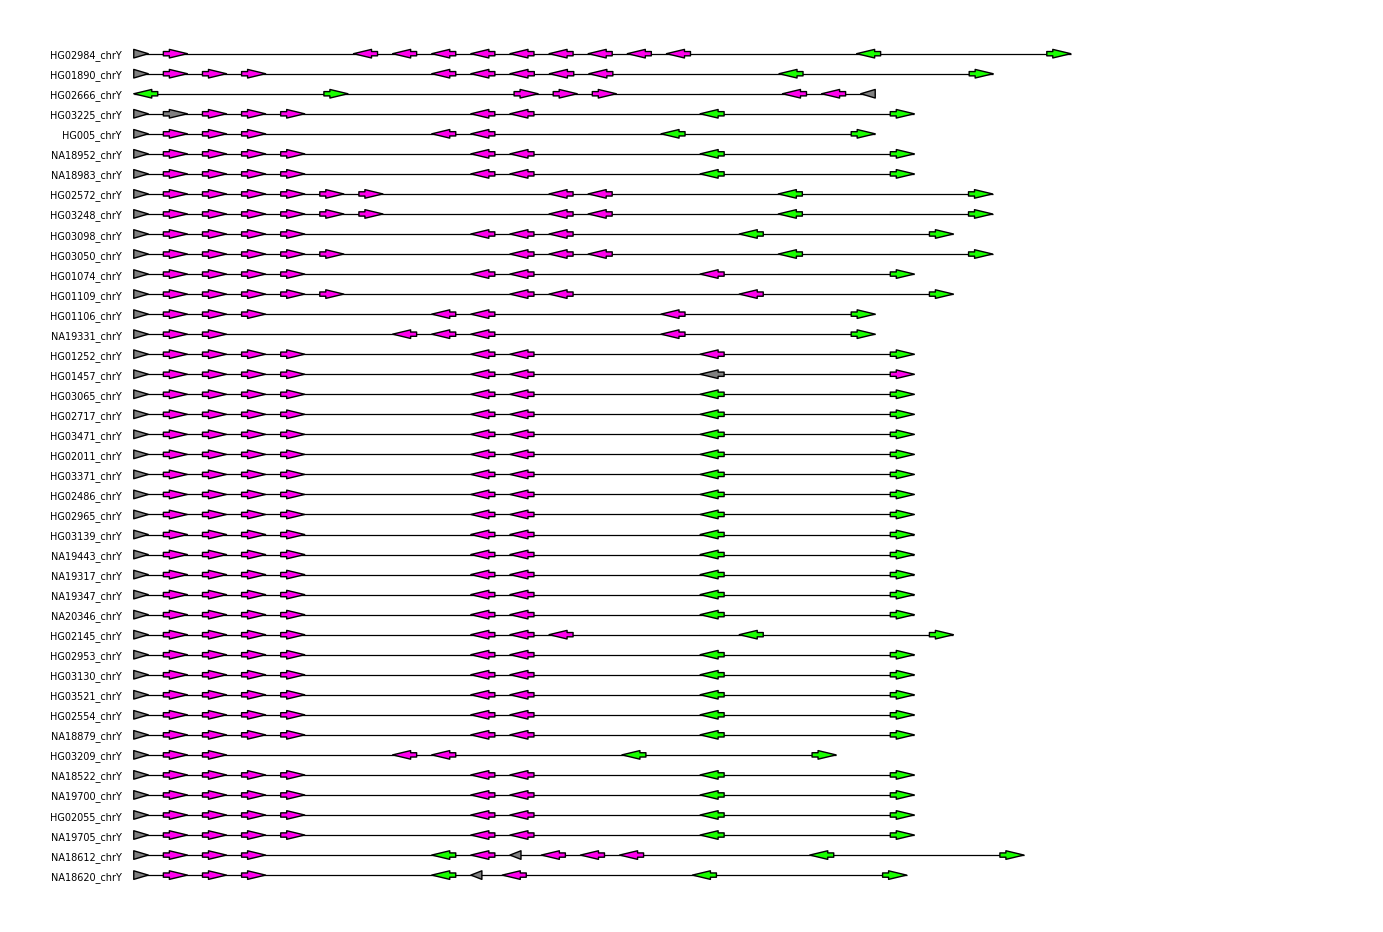

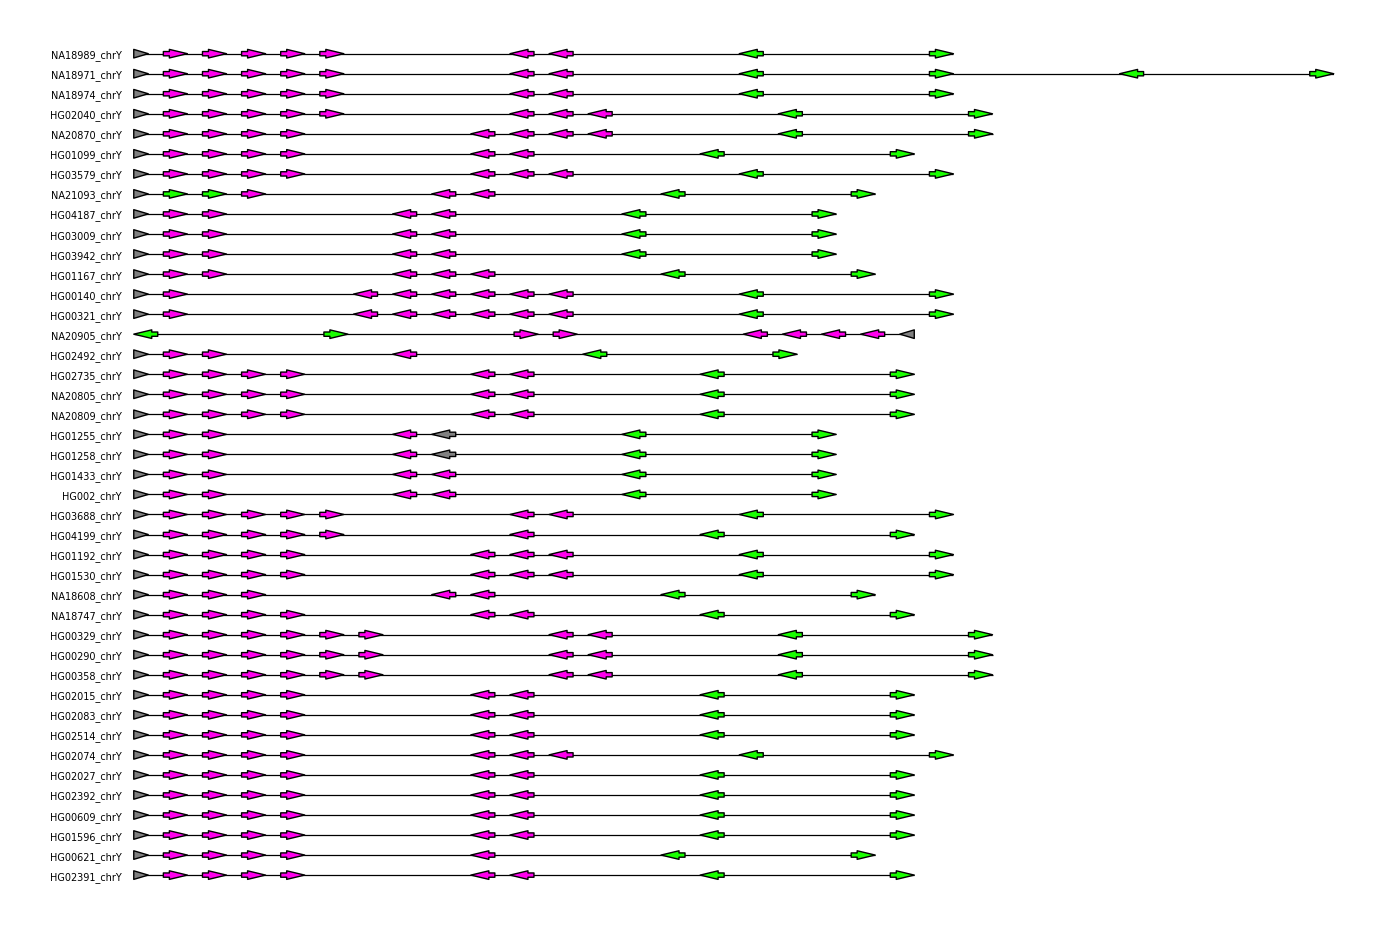

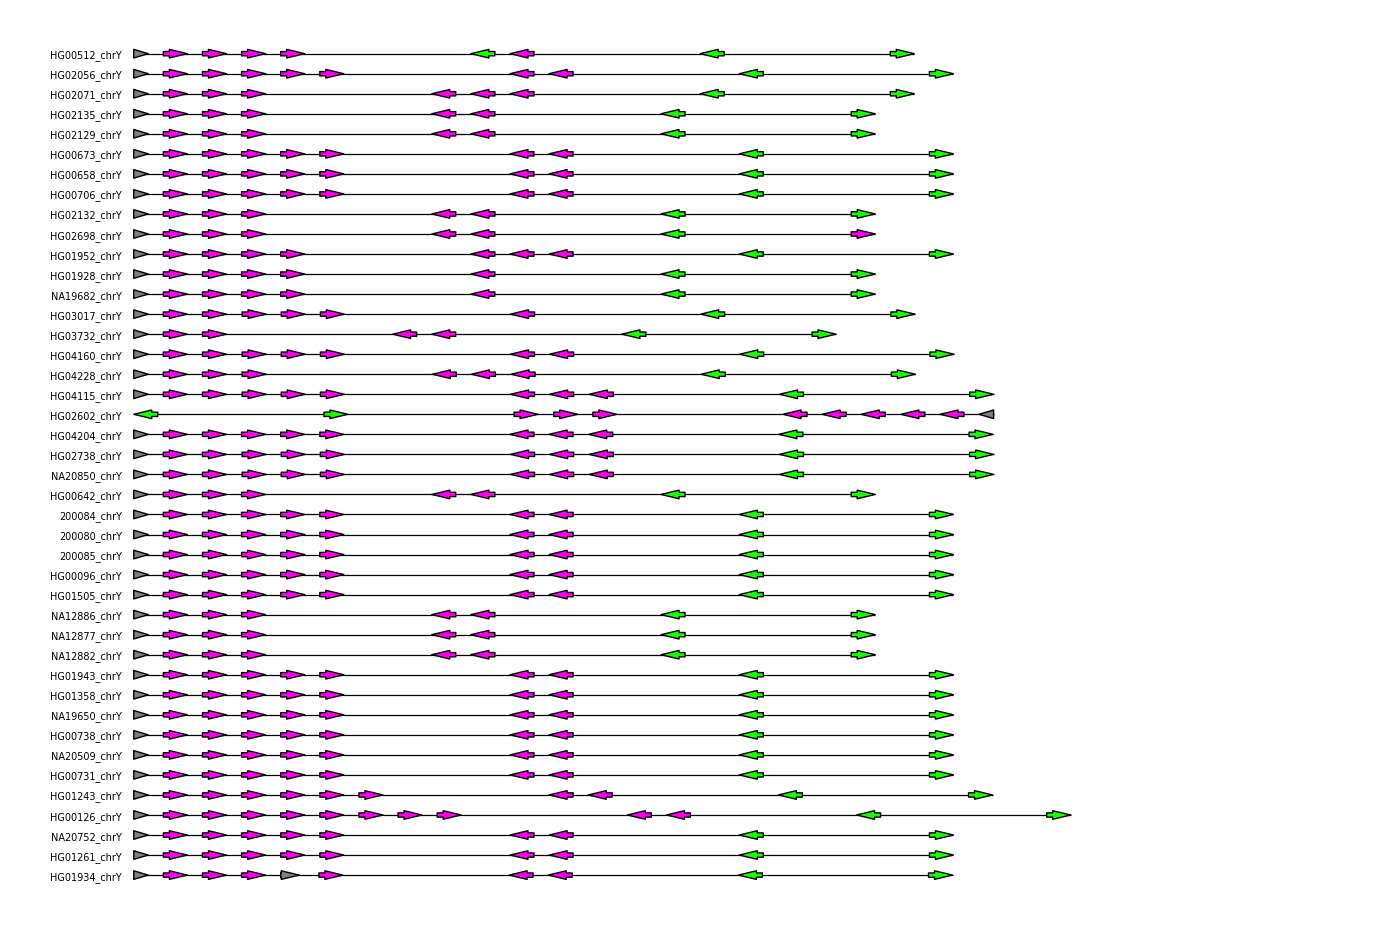

In [14]:
import math
from pygenomeviz import GenomeViz

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

dbgapssamples = {'NA12883','NA12884'}
multiContigs = ['HG03456_chrY_1', 'HG03456_chrY_2']

plot_order = [s for s in phylogeneticOrder if s not in dbgapssamples]

track_ids = []
for sample in plot_order:
    if sample == "HG03456":
        track_ids.extend(multiContigs)
    else:
        track_ids.append(sample + "_chrY")

seen = set()
ordered_genomes = []
for tid in track_ids:
    for genome in by_sample.get(tid, []):
        gname = genome["name"]
        if gname in seen:
            continue
        seen.add(gname)
        ordered_genomes.append(genome)

global_size = max(int(g["size"]) + 1 for g in ordered_genomes) if ordered_genomes else 1
print("global_size:", global_size)

per_fig = math.ceil(len(ordered_genomes) / 3)

for page_idx, genome_chunk in enumerate(chunks(ordered_genomes, per_fig), start=1):
    gv = GenomeViz(fig_width=12, fig_track_height=0.1, feature_track_ratio=0.75)

    for genome in genome_chunk:
        gname = genome["name"]
        real_size = int(genome["size"]) + 1
        features = genome["features"]

        sample_id = gname.split("_chrY")[0] if "_chrY" in gname else gname
        label_color = "red" if sample_id in samplesWithRandomHits else "black"

        track = gv.add_feature_track(
            gname,
            global_size,
            labelsize=7,
            label_kws={"color": label_color},
            line_kws={"lw": 0, "alpha": 0},  
        )

        for feature in features:
            start, end, strand, totalExons, contig, color, pseudogeneColor, motifClusterColor = feature
            start = int(start); end = int(end)

            if motifClusterColor == "temp":
                fc = "grey"
            else:
                fc = motifClusterColor if motifClusterColor else "black"

            hatch = None
            strand_dir = 1 if strand == "+" else -1

            track.add_feature(
                start, end, strand_dir,
                plotstyle="bigarrow",
                facecolor=fc,
                hatch=hatch,
                lw=1,
                ec="black",
            )


    fig = gv.plotfig()

    for ax in fig.axes:
        if ax.has_data():
            ax.set_xlim(0, global_size)

    track_axes = [ax for ax in fig.axes if ax.has_data()]
    for ax, genome in zip(track_axes, genome_chunk):
        real_size = int(genome["size"]) + 1
        y0, y1 = ax.get_ylim()
        ymid = (y0 + y1) / 2.0

        ax.hlines(
            y=ymid,
            xmin=0,
            xmax=real_size,
            colors="black",
            linewidth=0.9,
            zorder=1,
        )

    out_pdf = f"/RBMY_TFClusters_page{page_idx}_Jan202026.pdf"
    out_jpg = f"/RBMY_TFClusters_page{page_idx}_Jan202026.jpg"
    fig.savefig(out_pdf)
    fig.savefig(out_jpg, dpi=300)
    print("Saved", out_pdf)
